# Beamlet Dose Prediction and Beamlet Influence Matrix Optimization

This notebook demonstrates the beamlet dose prediction workflow in `portpy.ai`:

1. Preprocess beamlet dose data.
2. Train a beamlet dose prediction model.
3. Test the beamlet model and save beamlet/patient-level metrics.
4. Infer a predicted influence matrix, `A_pred`, for one patient.
5. Optimize fluence using `A_pred`.
6. Compare DVHs using `A_full @ x_actual` versus `A_full @ x_pred`.

The beamlet model predicts individual beamlet dose columns using CT and beamlet geometry features. The final treatment-plan comparison evaluates both fluence maps on the full/actual physical dose matrix for a fair DVH comparison.

## 0. Imports and paths

Update these paths for your local PortPy setup. The Windows DLL/OpenMP lines are usually only needed for a local Windows/PyCharm environment and can be removed on Linux/HPC.

In [1]:
import os
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import torch
import portpy.photon as pp

from portpy.ai.preprocess.beamletdose_preprocess import beamletdose_preprocess
from portpy.ai.preprocess.build_apred_batch import build_predicted_influence_matrix_for_patient
from portpy.ai.train import train
from portpy.ai.test import test

C:\Users\JhanwarG\.conda\envs\PortPy\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Raw PortPy data directory. This should contain patient folders and metadata.
in_dir = "../data"

# Preprocessed beamlet data root. Expected split layout after preprocessing/splitting:
#   ai_beamlet_data/train/Patient_x/...
#   ai_beamlet_data/val/Patient_x/...
#   ai_beamlet_data/test/Patient_x/...
beamlet_data_root = "../ai_beamlet_data"

checkpoints_dir = "../checkpoints"
results_dir = "../results"

## 1. Preprocess beamlet data

Run this section only when preprocessed beamlet data are not already available. After preprocessing, manually split patient folders into `train`, `val`, and `test` folders under `beamlet_data_root`.

You can preprocess either by downloading selected beams from Hugging Face metadata/data, or by using an already downloaded local PortPy dataset.

In [ ]:
patients = [f"Lung_Patient_{i}" for i in range(2, 101)]
# Add prostate patients if desired:
# patients += [f"Prostate_Patient_{i}" for i in range(1, 130)]

# Option A: download selected metadata/data from Hugging Face and preprocess.
# Uncomment when needed.
# beamletdose_preprocess(
#     patient_ids=patients,
#     meta_stage_root="../../PortPy_MetadataOnly",
#     data_stage_root="../../PortPy_Dataset_SelectedBeams",
#     out_root=beamlet_data_root,
# )

# Option B: preprocess from already downloaded local PortPy data.
# Uncomment when needed.
# beamletdose_preprocess(
#     patient_ids=patients,
#     local_data_dir=in_dir,
#     out_root=beamlet_data_root,
# )

## 2. Train beamlet dose prediction model

This uses the same beamlet UNet model (`beamlet_unet`) and the beamlet dataset (`beamletdose3d`).

In [ ]:
train_options = {
    "dataroot": beamlet_data_root,
    "checkpoints_dir": checkpoints_dir,
    "name": "portpy_beamlet_unet",
    "model": "beamletdose3d",
    "dataset_mode": "beamletdose3d",
    "netG": "beamlet_unet",
    "input_nc": 4,
    "output_nc": 1,
    "norm": "none",  # beamlet_unet uses GroupNorm internally; this option is ignored by beamlet_unet
    "batch_size": 2,
    "num_threads": 2,
    "lr": 1e-4,
    "n_epochs": 100,
    "n_epochs_decay": 0,
    "display_id": -1,
    "display_freq": 100,
    "print_freq": 10,
    "gpu_ids": [0],
    "val_phase": "val",
    "lr_policy": "plateau",
    "lambda_bg": 0.0005,
}

# Uncomment to train.
# train(train_options)

## 3. Test beamlet model

For beamlet dose prediction, use `test_task="beamlet_dose_prediction"`. This avoids writing HTML/images for every beamlet and instead saves beamlet-level and patient-level metrics.

In [ ]:
test_options = {
    "dataroot": beamlet_data_root,
    "checkpoints_dir": checkpoints_dir,
    "results_dir": results_dir,
    "name": "portpy_beamlet_unet",
    "model": "beamletdose3d",
    "dataset_mode": "beamletdose3d",
    "netG": "beamlet_unet",
    "input_nc": 4,
    "output_nc": 1,
    "phase": "test",
    "eval": True,
    "norm": "none",
    "lambda_bg": 0.0005,
    "epoch": "best_mae",  # loads best_mae_net_G.pth
    "test_task": "beamlet_dose_prediction",
}

# Uncomment to test.
# test(test_options)

## 4. Infer predicted influence matrix for one patient

This builds `A_pred` by predicting each beamlet dose column and resampling predictions back to the CT grid. If preprocessed beamlet data for this patient are missing, use your updated `build_predicted_influence_matrix_for_patient(..., raw_data_dir=in_dir)` version or preprocess the patient first.

In [4]:
patient_id = "Lung_Patient_94"
protocol_name = "Lung_2Gy_30Fx"

# Load patient data.
data = pp.DataExplorer(data_dir=in_dir)
data.patient_id = patient_id

ct = pp.CT(data)
structs = pp.Structures(data)

# Use the same deterministic beam selection used during preprocessing/build_apred.
from portpy.ai.preprocess.build_apred_batch import deterministic_beam_ids, get_ct_image, load_unet_model

beam_ids = deterministic_beam_ids(data, patient_id)
# Full/actual influence matrix.
beams = pp.Beams(data, beam_ids=beam_ids, load_inf_matrix_full=True)
inf_matrix = pp.InfluenceMatrix(ct=ct, structs=structs, beams=beams, is_full=True)
ct_img = get_ct_image(ct)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = os.path.join(checkpoints_dir, "portpy_beamlet_unet", "best_mae_net_G.pth")
model = load_unet_model(ckpt_path, device)

A_pred = build_predicted_influence_matrix_for_patient(
    patient_id=patient_id,
    data_root=beamlet_data_root,
    split="test",
    ct_img=ct_img,
    inf_matrix=inf_matrix,  # used for dimensions and dose_3d_to_1d mapping
    model=model,
    device=device,
    batch_size=2,
    num_workers=0,
    # raw_data_dir=in_dir,  # uncomment if your you dont have patient preprocessed. it supports on-the-fly preprocessing
)

Creating BEV..
Loading sparse influence matrix...
Done


## 5. Optimize fluence using predicted beamlet matrix

This is a simple example objective. In practice, users can replace it with their standard PortPy optimization parameters.

In [5]:
from copy import deepcopy
from scipy import sparse

clinical_criteria = pp.ClinicalCriteria(data, protocol_name=protocol_name)
opt_params = data.load_config_opt_params(protocol_name=protocol_name)

A_gt = deepcopy(inf_matrix.A).astype(np.float32)

# Sparse thresholded actual matrix.
thr_gt = 0.01 * np.max(A_gt)
S_gt = sparse.csr_matrix(np.where(A_gt >= thr_gt, A_gt, 0.0))

# Sparse thresholded predicted matrix.
A_pred[A_pred < 0] = 0.0
thr_pred = 0.01 * np.max(A_pred) if np.max(A_pred) > 0 else 0.0
S_pred = sparse.csr_matrix(np.where(A_pred >= thr_pred, A_pred, 0.0))

# Solve using predicted beamlet matrix.
inf_matrix.A = S_pred
plan_pred = pp.Plan(
    ct=ct,
    structs=structs,
    beams=beams,
    inf_matrix=inf_matrix,
    clinical_criteria=clinical_criteria,
)
opt_pred = pp.Optimization(plan_pred, opt_params=opt_params, clinical_criteria=clinical_criteria)
opt_pred.create_cvxpy_problem()
sol_pred = opt_pred.solve(solver="MOSEK", verbose=False)
x_pred = sol_pred["optimal_intensity"] * plan_pred.get_num_of_fractions()

Creating BEV..
Loading full influence matrix..
Done
Problem created
Running Optimization..
Optimal value: 28.91689255254863
Elapsed time: 27.13232922554016 seconds


## 6. Compare DVH: ground truth vs predicted influence matrix

For a fair clinical comparison, both fluence maps are evaluated on the actual/full physical influence matrix `A_full`:

- `A_full @ x_actual`: fluence optimized using the actual matrix.
- `A_full @ x_pred`: fluence optimized using the predicted matrix, then evaluated on the actual matrix.

In [6]:
# Solve using actual/full beamlet matrix.
inf_matrix.A = S_gt
plan_gt = pp.Plan(
    ct=ct,
    structs=structs,
    beams=beams,
    inf_matrix=inf_matrix,
    clinical_criteria=clinical_criteria,
)
opt_gt = pp.Optimization(plan_gt, opt_params=opt_params, clinical_criteria=clinical_criteria)
opt_gt.create_cvxpy_problem()
sol_gt = opt_gt.solve(solver="MOSEK", verbose=False)
x_actual = sol_gt["optimal_intensity"] * plan_gt.get_num_of_fractions()

# Fair comparison: evaluate both fluence maps on actual/full matrix.
dose_gt_1d = A_gt @ x_actual      # A_full @ x_actual
dose_pred_1d = A_gt @ x_pred      # A_full @ x_pred

Problem created
Running Optimization..
Optimal value: 25.91717292101996
Elapsed time: 16.18477964401245 seconds


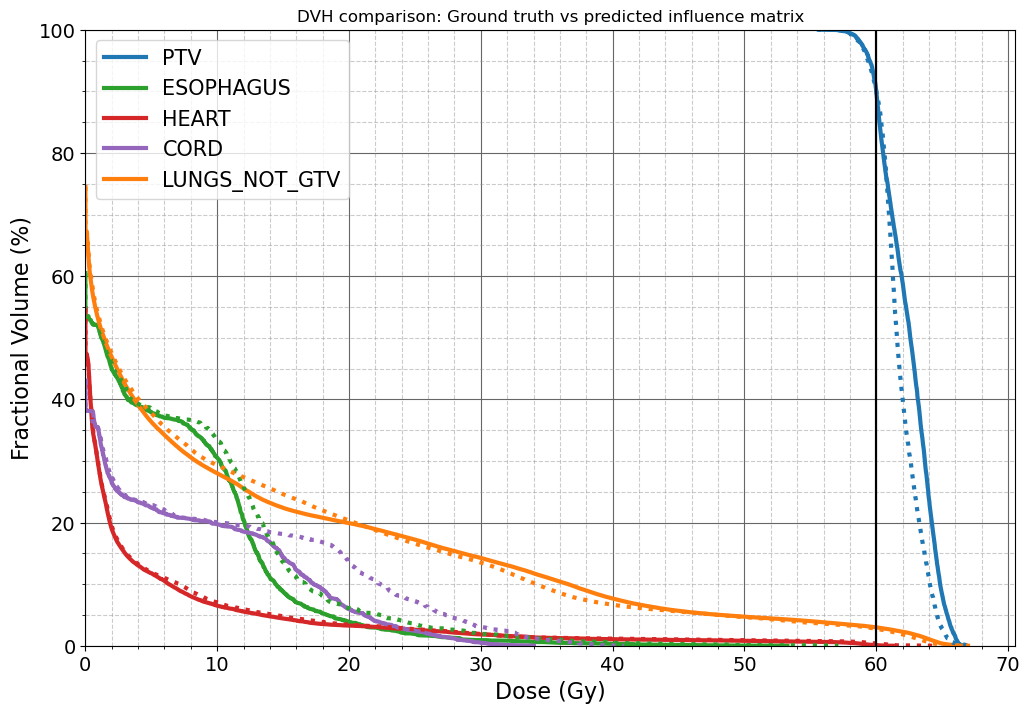

In [9]:
if "lung" in patient_id.lower():
    struct_names = ["PTV", "ESOPHAGUS", "HEART", "CORD", "LUNG_L", "LUNG_R", "LUNGS_NOT_GTV"]
else:
    struct_names = ["PTV", "BLADDER", "RECTUM", "FEMUR_L", "FEMUR_R"]

fig, ax = plt.subplots(figsize=(12, 8))

ax = pp.Visualization.plot_dvh(
    plan_gt,
    dose_1d=dose_gt_1d,
    struct_names=struct_names,
    style="solid",
    ax=ax,
    norm_flag=True,
)

ax = pp.Visualization.plot_dvh(
    plan_gt,
    dose_1d=dose_pred_1d,
    struct_names=struct_names,
    style="dotted",
    ax=ax,
    norm_flag=True,
)

ax.set_title("DVH comparison: Ground truth vs predicted influence matrix")
plt.show()